# Car insurance claim project — EDA & pipeline walkthrough

This notebook is for exploration and demonstration only. All real logic (cleaning,
preprocessing, training, evaluation) lives in `src/` and is tested in `tests/` —
this notebook just calls into it and visualizes the results, so there's no logic
duplicated here that could drift out of sync with the actual pipeline.

See `DECISIONS.md` for the reasoning behind each modeling choice, and `README.md`
for how to run everything from the command line instead of a notebook.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, '../src')

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from data import load_and_clean
from features import build_preprocess_pipeline
from train import build_classification_split, build_regression_split, make_claim_value_bins
from evaluate import evaluate_classifier, evaluate_regressor, shap_feature_importance

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

z:\aplus_workshop\insurance-portfolio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and clean the data

Uses `src/data.py` — the exact same cleaning function `src/train.py` uses, so this notebook can never silently drift from what actually gets trained.

In [2]:
df = load_and_clean('../data/car_insurance_claim.csv')
print(df.shape)
df.head()

(10301, 25)


,num_young_drivers,age,num_of_children,years_job_held_for,income,single_parent,value_of_home,married,gender,highest_education,occupation,commute_dist,type_of_use,vehicle_value,policy_tenure,vehicle_type,red_vehicle,5_year_total_claims_value,5_year_num_of_claims,licence_revoked,license_points,new_claim_value,vehicle_age,is_claim,address_type
0,0,60.0,0,11.0,67349,No,0,No,M,PhD,Professional,14,Private,14230,11,Minivan,yes,4461,2,No,3,0,18.0,0,Highly Urban/ Urban
1,0,43.0,0,11.0,91449,No,257252,No,M,High School,Blue Collar,22,Commercial,14940,1,Minivan,yes,0,0,No,0,0,1.0,0,Highly Urban/ Urban
2,0,48.0,0,11.0,52881,No,0,No,M,Bachelors,Manager,26,Private,21970,1,Van,yes,0,0,No,2,0,10.0,0,Highly Urban/ Urban
3,0,35.0,1,10.0,16039,No,124191,Yes,F,High School,Clerical,5,Private,4010,4,SUV,no,38690,2,No,3,0,10.0,0,Highly Urban/ Urban
4,0,51.0,0,14.0,<NA>,No,306251,Yes,M,<High School,Blue Collar,32,Private,15440,7,Minivan,yes,0,0,No,0,0,6.0,0,Highly Urban/ Urban


In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
num_young_drivers,10301.0,NaN,NaN,NaN,0.169304,0.506533,0.0,0.0,0.0,0.0,4.0
age,10294.0,NaN,NaN,NaN,44.837964,8.606671,16.0,39.0,45.0,51.0,81.0
num_of_children,10301.0,NaN,NaN,NaN,0.720513,1.116355,0.0,0.0,0.0,1.0,5.0
years_job_held_for,9753.0,NaN,NaN,NaN,10.4737,4.108999,0.0,9.0,11.0,13.0,23.0
income,9731.0,<NA>,<NA>,<NA>,61568.83568,47458.566563,0.0,27583.0,53526.0,86139.5,367030.0
single_parent,10301,2,No,8958,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value_of_home,9726.0,<NA>,<NA>,<NA>,154513.740284,129191.840215,0.0,0.0,160629.0,238251.25,885282.0
married,10301,2,Yes,6187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,10301,2,F,5545,NaN,NaN,NaN,NaN,NaN,NaN,NaN
highest_education,10301,5,High School,2952,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Target distributions

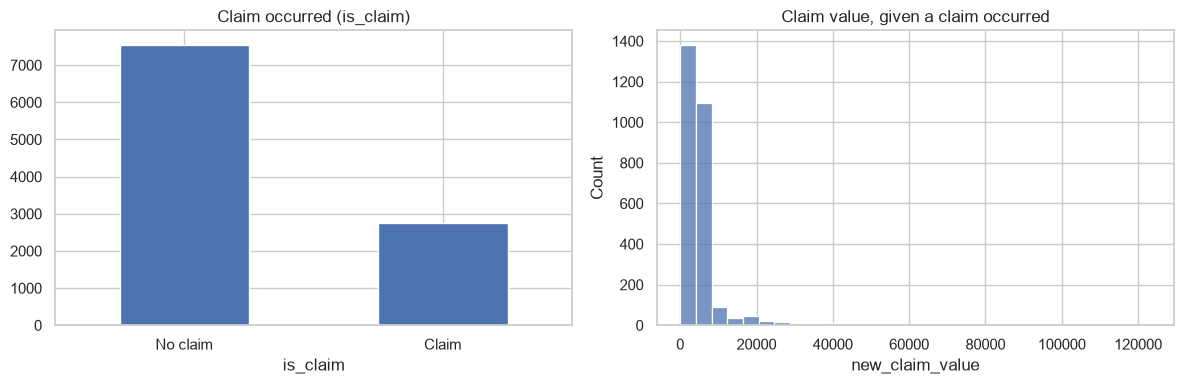

Claim rate: 26.7%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['is_claim'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Claim occurred (is_claim)')
axes[0].set_xticklabels(['No claim', 'Claim'], rotation=0)

sns.histplot(df.loc[df['new_claim_value'] > 0, 'new_claim_value'], bins=30, ax=axes[1])
axes[1].set_title('Claim value, given a claim occurred')
axes[1].set_xlabel('new_claim_value')

plt.tight_layout()
plt.show()

print(f"Claim rate: {df['is_claim'].mean():.1%}")

## 3. Numerical feature distributions

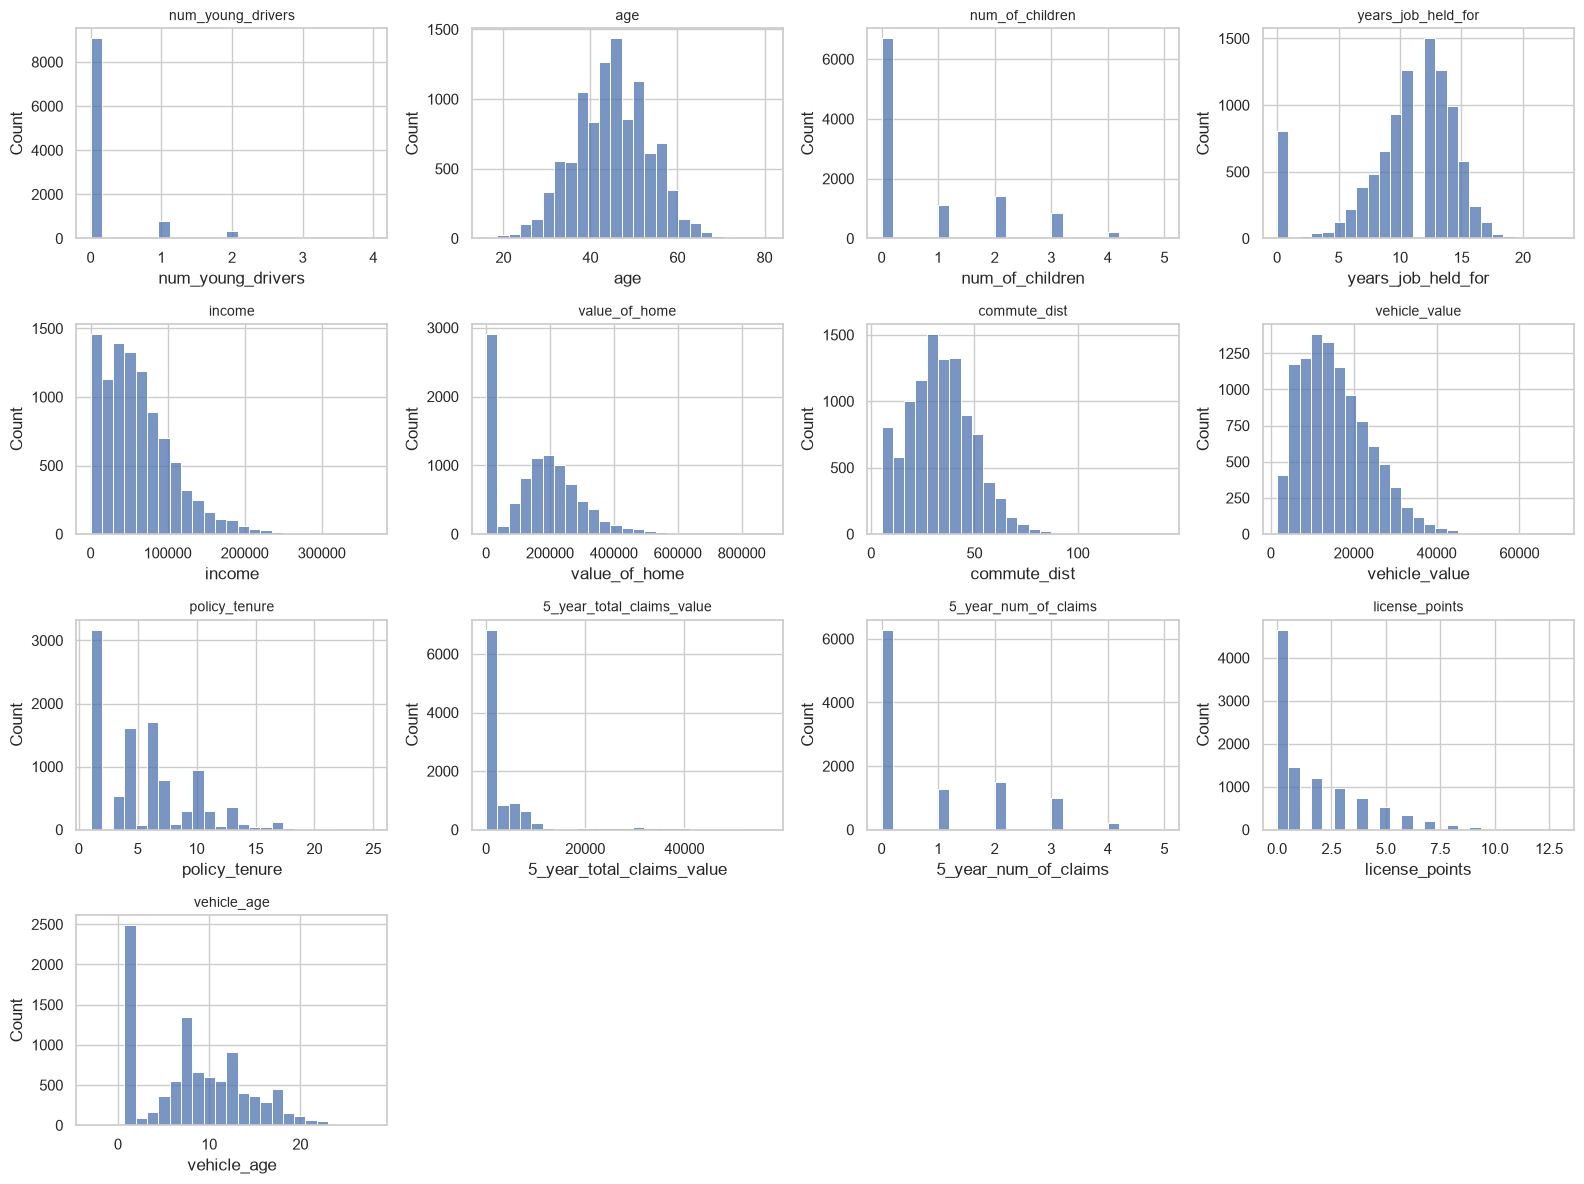

In [5]:
numerical_cols = [
    'num_young_drivers', 'age', 'num_of_children', 'years_job_held_for',
    'income', 'value_of_home', 'commute_dist', 'vehicle_value',
    'policy_tenure', '5_year_total_claims_value', '5_year_num_of_claims',
    'license_points', 'vehicle_age',
]

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, col in zip(axes.flat, numerical_cols):
    sns.histplot(df[col].dropna(), bins=25, ax=ax)
    ax.set_title(col, fontsize=10)
for ax in axes.flat[len(numerical_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Correlation with the classification target

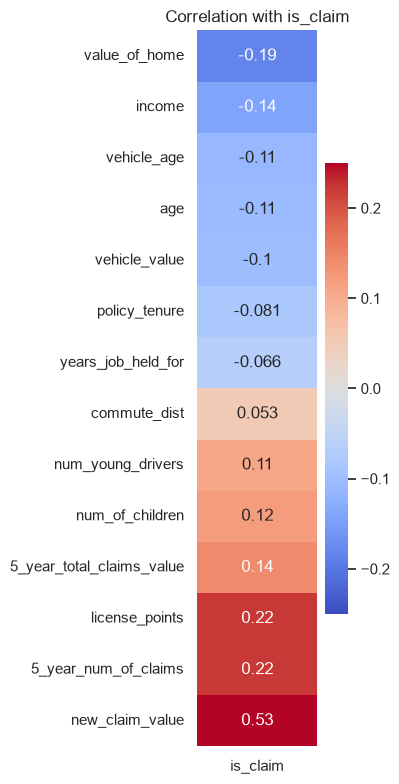

In [6]:
corr = df.select_dtypes(include=[np.number]).corr()[['is_claim']].drop(index='is_claim')
corr = corr.sort_values('is_claim')

fig, ax = plt.subplots(figsize=(4, 8))
sns.heatmap(corr, cmap='coolwarm', annot=True, vmin=-0.25, vmax=0.25, ax=ax)
plt.title('Correlation with is_claim')
plt.tight_layout()
plt.show()

## 5. Preprocessing pipeline (from `src/features.py`)

Same `build_preprocess_pipeline()` used inside the real training `Pipeline` — fitting it here on a sample is just to inspect the output shape, not a separate code path.

In [7]:
X_train, X_test, y_train, y_test = build_classification_split(df)

preprocess = build_preprocess_pipeline()
X_train_prepared = preprocess.fit_transform(X_train)
print('Transformed shape:', X_train_prepared.shape)
X_train_prepared.head()

Transformed shape: (8240, 32)


,num__num_young_drivers,num__age,num__num_of_children,num__years_job_held_for,num__income,num__value_of_home,num__commute_dist,num__vehicle_value,num__policy_tenure,num__5_year_total_claims_value,num__5_year_num_of_claims,num__license_points,num__vehicle_age,cat_ord__highest_education,cat_bin__single_parent,cat_bin__married,cat_bin__gender,cat_bin__type_of_use,cat_bin__licence_revoked,cat_bin__address_type,cat_one_hot__occupation_Clerical,cat_one_hot__occupation_Doctor,cat_one_hot__occupation_Home Maker,cat_one_hot__occupation_Lawyer,cat_one_hot__occupation_Manager,cat_one_hot__occupation_Professional,cat_one_hot__occupation_Student,cat_one_hot__vehicle_type_Panel Truck,cat_one_hot__vehicle_type_Pickup,cat_one_hot__vehicle_type_SUV,cat_one_hot__vehicle_type_Sports Car,cat_one_hot__vehicle_type_Van
8452,-0.332668,1.409817,-0.643344,-2.563674,-0.375723,-1.452458,0.498062,-1.040804,1.139483,-0.461230,-0.691403,0.092242,-1.295667,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7822,3.669060,-0.453096,2.054902,0.874127,-0.866152,0.037836,-0.479232,-1.159364,-0.142286,-0.461230,-0.691403,0.878344,-1.295667,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1312,-0.332668,-1.850281,1.155487,0.383013,0.090791,0.424047,0.443522,-2.392885,-0.142286,0.161972,0.177994,1.419574,-0.405338,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
921,-0.332668,0.129064,0.256071,0.628570,0.258015,0.569484,-0.929180,0.845452,-1.245093,0.147137,0.177994,1.648754,-0.405338,2.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8708,-0.332668,-0.685960,-0.643344,-0.599216,1.093996,1.062875,-0.409978,-1.374057,-1.245093,-0.461230,-0.691403,0.092242,-0.583403,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


## 6. Load the trained models

These were trained with `python src/train.py` (optionally using Optuna-tuned
hyperparameters from `python src/tune.py`) — this notebook loads the saved
artifacts rather than retraining, so it stays fast to re-run.

In [8]:
clf_pipeline = joblib.load('../models/classifier_pipeline.joblib')
reg_pipeline = joblib.load('../models/regressor_pipeline.joblib')
print('Loaded classifier:', clf_pipeline.named_steps['model'])
print('Loaded regressor:', reg_pipeline.named_steps['model'])

Loaded classifier: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8478691453298082, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.011998184497560183, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.021692753688682165, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=13, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=313, n_jobs=None,
              num_parallel_tree=None, ...)
Loaded regressor: SGDRegressor(alpha=0.004, eta0=0.003, max_iter=200, random_state=42, tol=1e-05)


## 7. Evaluation on the held-out test set

Uses `.predict()`/`.predict_proba()` on the fitted `Pipeline` directly — preprocessing is only ever `.transform()`-ed here, never re-fit. See `DECISIONS.md` for why this matters.

In [9]:
clf_metrics = evaluate_classifier(clf_pipeline, X_test, y_test)
clf_metrics

{'f1_weighted': 0.782674194502225,
 'roc_auc': 0.8255873449025712,
 'pr_auc_average_precision': 0.6425630990490881,
 'positive_class_rate_test': 0.27365356622998543}

In [10]:
Xr_train, Xr_test, yr_train, yr_test = build_regression_split(df)
reg_metrics = evaluate_regressor(reg_pipeline, Xr_test, yr_test)
reg_metrics

{'rmse': 8381.073880450047,
 'mae': 3549.3347349297424,
 'baseline_rmse': 8285.106663145973,
 'baseline_mae': 3309.639233057851,
 'rmse_improvement_pct': -1.158309979652505}

**Note:** the regressor's RMSE here is close to (and can be slightly worse than) the
naive mean-baseline RMSE. This is a real, leakage-free finding — see `DECISIONS.md`
for why claim severity appears only weakly predictable from these features, and why
that's reported honestly rather than hidden.

## 8. Feature importance (SHAP)

In [11]:
clf_importance = shap_feature_importance(
    clf_pipeline, X_test.sample(min(300, len(X_test)), random_state=42), top_n=10,
)
pd.DataFrame(clf_importance)

,feature,mean_abs_shap
0,cat_bin__address_type,0.497122
1,cat_bin__type_of_use,0.301585
2,num__5_year_total_claims_value,0.276480
3,cat_ord__highest_education,0.225158
4,cat_bin__married,0.196519
5,num__age,0.194072
6,num__value_of_home,0.188641
7,num__policy_tenure,0.181189
8,num__commute_dist,0.175777
9,cat_bin__licence_revoked,0.162541


In [12]:
reg_importance = shap_feature_importance(
    reg_pipeline, Xr_test.sample(min(300, len(Xr_test)), random_state=42), top_n=10,
)
pd.DataFrame(reg_importance)

Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.


,feature,mean_abs_shap
0,num__vehicle_value,729.978207
1,cat_bin__gender,585.562991
2,num__vehicle_age,544.358171
3,cat_ord__highest_education,419.448188
4,cat_one_hot__vehicle_type_SUV,381.993762
5,cat_bin__single_parent,297.033765
6,num__policy_tenure,219.839331
7,cat_bin__licence_revoked,187.196099
8,cat_one_hot__occupation_Professional,153.202765
9,num__age,149.309567


## Next steps

- Full CLI workflow (train / tune / evaluate / serve) is documented in `README.md`.
- Design rationale for every choice above is in `DECISIONS.md`.
- The trained models here are served via `src/serve.py` (FastAPI) and deployed
  through the CDK stack in `infra/`.